In [4]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.graph import StateGraph,START,END

In [5]:
docs = TextLoader("research_notes.txt",encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size = 500 , chunk_overlap = 50)
chunks = splitter.split_documents(docs)
embedding = HuggingFaceEmbeddings()
vectorestore  = FAISS.from_documents(chunks,embedding)
retriever = vectorestore.as_retriever()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [7]:
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001C8A2E67B10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C8D1514550>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
class RagCOTstate(BaseModel):
    question:str
    sub_steps:list[str] = []
    retrieved_docs:List[Document] = []
    answer:str = ""

In [9]:
def plan_steps(state:RagCOTstate)->RagCOTstate:
    prompt = f"Break The Question into 2-2 reasoning Steps:\n\n{state.question}"
    result = llm.invoke(prompt).content
    subq = [line.strip(" -") for line in result.split("\n")if line.strip()]
    
    
    return state.model_copy(update={"sub_steps":subq})

In [10]:
def retrive_per_step(state:RagCOTstate)->RagCOTstate:
    all_doc = []
    for sub in state.sub_steps:
        docs = retriever.invoke(sub)
        all_doc.extend(docs)
    return state.model_copy(update={"retrieved_docs":all_doc})    

In [12]:
def generate_answer(state:RagCOTstate)->RagCOTstate:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f""" 
        You are answering a complex question using reasoning and retrieved documents.
        Question :{state.question}
        
        
        relevant_info:
        {context}
        
        
        now synthesized a well-reasoned final answer
    
    
    """
    
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer":result})

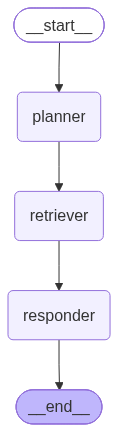

In [13]:
builder = StateGraph(RagCOTstate)
builder.add_node("planner",plan_steps)
builder.add_node("retriever",retrive_per_step)
builder.add_node("responder",generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner","retriever")
builder.add_edge("retriever","responder")
builder.add_edge("responder",END)


graph = builder.compile()
graph

In [16]:
if __name__ == "__main__":
    query = """
    Explain how Agentic RAG improves upon traditional RAG.
    Describe the complete workflow, including document retrieval,
    """

    state = RagCOTstate(question=query)

    final = graph.invoke(state)

    print(final["answer"])

**Agentic Retrieval‑Augmented Generation (Agentic RAG)**  
is an evolution of the classic RAG pipeline that adds *decision‑making* and *control flow* to the process.  
Instead of a single, fixed “retrieve‑then‑generate” chain, an **agent** (usually a LLM equipped with a small set of tools) can inspect intermediate results, decide whether they are good enough, and dynamically invoke additional steps such as query rewriting, extra retrieval passes, tool calls, or even fallback strategies.  

Below is a concise comparison followed by a **complete, step‑by‑step workflow** that illustrates how an Agentic RAG system operates in practice (e.g., a university‑assistant use‑case).

---

## 1. Why Agentic RAG Improves on Traditional RAG  

| Aspect | Traditional RAG | Agentic RAG |
|--------|----------------|------------|
| **Control flow** | Linear: *query → retrieve → generate*. No feedback loop. | Dynamic graph: the agent can branch, loop, or terminate based on intermediate signals. |
| **Reli